<a href="https://colab.research.google.com/github/JIUCHOI/zuzuggongzu/blob/main/Stewart_SCLC_public_RNA_seq_reanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Colab 환경 세팅

In [6]:
# =========================
# Step 1. Install packages
# =========================

!pip -q install pandas==2.2.2
!pip -q install scanpy==1.10.4 anndata==0.10.9
!pip -q install GEOparse mygene gseapy statsmodels scikit-learn tqdm leidenalg

In [7]:
# =========================
# Step 2. Import packages
# =========================

from pathlib import Path
import os
import re
import tarfile
import gzip
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from scipy import stats
from scipy import io as scipy_io
from scipy import sparse
from statsmodels.stats.multitest import multipletests

import GEOparse
import mygene
import gseapy as gp

warnings.filterwarnings("ignore")

In [8]:
# =========================
# Step 3. Google Drive mount
# =========================

USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/SCLC_Stewart_GSE138474")
else:
    PROJECT_DIR = Path("/content/SCLC_Stewart_GSE138474")

RAW_DIR = PROJECT_DIR / "data_raw"
PROC_DIR = PROJECT_DIR / "data_processed"
RESULTS_DIR = PROJECT_DIR / "results"
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

for d in [RAW_DIR, PROC_DIR, RESULTS_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SCLC_Stewart_GSE138474


In [9]:
# =========================
# Step 4. Utility functions
# =========================

def wget_if_missing(url, out_path):
    out_path = Path(out_path)
    if out_path.exists() and out_path.stat().st_size > 0:
        print(f"[exists] {out_path.name}")
        return out_path

    print(f"[download] {out_path.name}")
    subprocess.run(
        ["wget", "-c", "-O", str(out_path), url],
        check=True
    )
    return out_path


def parse_geo_metadata(gse):
    """
    GEOparse GSE object에서 sample metadata를 DataFrame으로 변환.
    characteristics_ch1: ['tissue: CTC', 'treatment: untreated'] 같은 형식을 파싱.
    """
    rows = []
    for gsm_id, gsm in gse.gsms.items():
        row = {
            "gsm": gsm_id,
            "title": gsm.metadata.get("title", [""])[0],
            "source_name": gsm.metadata.get("source_name_ch1", [""])[0],
            "organism": gsm.metadata.get("organism_ch1", [""])[0],
        }

        chars = gsm.metadata.get("characteristics_ch1", [])
        for item in chars:
            if ": " in item:
                k, v = item.split(": ", 1)
                row[k.strip()] = v.strip()

        rows.append(row)

    return pd.DataFrame(rows)


def save_table(df, filename):
    out = TABLE_DIR / filename
    df.to_csv(out, index=True)
    print(f"[saved] {out}")

In [10]:
# =========================
# Step A1. Download GSE138418 bulk RNA-seq count matrix
# =========================

gse418_count_url = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE138nnn/"
    "GSE138418/suppl/GSE138418_SCLC.RNAseq.htseq_count.tsv.gz"
)

count_file = wget_if_missing(
    gse418_count_url,
    RAW_DIR / "GSE138418_SCLC.RNAseq.htseq_count.tsv.gz"
)

[exists] GSE138418_SCLC.RNAseq.htseq_count.tsv.gz


In [11]:
# =========================
# Step A2. Download and parse GEO metadata
# =========================

gse418 = GEOparse.get_GEO(geo="GSE138418", destdir=str(RAW_DIR), silent=True)
meta418 = parse_geo_metadata(gse418)

display(meta418.head())
print(meta418.shape)

save_table(meta418, "GSE138418_metadata_raw.csv")

,gsm,title,source_name,organism,disease state,tissue,sample type,treatment,platinum response
0,GSM4107771,SC16.A1465,MDA-SC16,Homo sapiens,Small cell lung cancer (SCLC),flank,CDX,untreated,resistant
1,GSM4107772,SC16.A1466,MDA-SC16,Homo sapiens,Small cell lung cancer (SCLC),flank,CDX,untreated,resistant
2,GSM4107773,SC16.A1467,MDA-SC16,Homo sapiens,Small cell lung cancer (SCLC),flank,CDX,untreated,resistant
3,GSM4107774,SC39.739_flank,MDA-SC39,Homo sapiens,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive
4,GSM4107775,SC39.963_flank,MDA-SC39,Homo sapiens,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive


(18, 9)
[saved] /content/drive/MyDrive/SCLC_Stewart_GSE138474/results/tables/GSE138418_metadata_raw.csv


In [12]:
# 주요 metadata 확인
cols_to_show = [c for c in [
    "gsm", "title", "source_name", "disease state", "tissue",
    "sample type", "treatment", "platinum response"
] if c in meta418.columns]

display(meta418[cols_to_show].sort_values("title"))

,gsm,title,source_name,disease state,tissue,sample type,treatment,platinum response
0,GSM4107771,SC16.A1465,MDA-SC16,Small cell lung cancer (SCLC),flank,CDX,untreated,resistant
1,GSM4107772,SC16.A1466,MDA-SC16,Small cell lung cancer (SCLC),flank,CDX,untreated,resistant
2,GSM4107773,SC16.A1467,MDA-SC16,Small cell lung cancer (SCLC),flank,CDX,untreated,resistant
3,GSM4107774,SC39.739_flank,MDA-SC39,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive
4,GSM4107775,SC39.963_flank,MDA-SC39,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive
5,GSM4107776,SC39.964_flank,MDA-SC39,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive
6,GSM4107777,SC4.435_flank,MDA-SC4,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive
7,GSM4107778,SC4.613_flank,MDA-SC4,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive
8,GSM4107779,SC4.616_flank,MDA-SC4,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive
9,GSM4107780,SC4.917_flank,MDA-SC4,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive


In [13]:
# =========================
# Step A3. Load count matrix
# =========================

counts = pd.read_csv(count_file, sep="\t", index_col=0)

# HTSeq special rows 제거: __no_feature, __ambiguous 등
counts = counts.loc[~counts.index.astype(str).str.startswith("__")]

# 숫자형 변환
counts = counts.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

print(counts.shape)
display(counts.iloc[:5, :5])
print(counts.columns[:10].tolist())

(49457, 18)


,SC4.435_flank,SC4.613_flank,SC4.616_flank,SC4.917_flank,SC4.918_flank
5S_rRNA,4,6,3,1,5
7SK,113,88,96,82,81
A1BG,28,37,28,25,17
A1BG-AS1,234,233,227,172,129
A1CF,0,0,0,0,0


['SC4.435_flank', 'SC4.613_flank', 'SC4.616_flank', 'SC4.917_flank', 'SC4.918_flank', 'SC4.920_flank', 'SC39.739_flank', 'SC39.963_flank', 'SC39.964_flank', 'SC16.A1465']


In [14]:
# =========================
# Step A4. Match count columns to metadata
# =========================

meta418 = meta418.copy()

# count matrix column이 GSM인지 title인지 확인 후 GSM으로 통일
title_to_gsm = dict(zip(meta418["title"], meta418["gsm"]))
gsm_to_title = dict(zip(meta418["gsm"], meta418["title"]))

if set(counts.columns).issubset(set(meta418["gsm"])):
    print("Count columns are GSM IDs.")
elif set(counts.columns).issubset(set(meta418["title"])):
    print("Count columns are sample titles. Renaming to GSM IDs.")
    counts = counts.rename(columns=title_to_gsm)
else:
    print("Warning: count columns are not perfectly matched. Inspect manually.")
    print("count columns:", counts.columns[:5].tolist())
    print("metadata GSM:", meta418["gsm"].head().tolist())
    print("metadata title:", meta418["title"].head().tolist())

meta418 = meta418.set_index("gsm")
meta418 = meta418.loc[[c for c in counts.columns if c in meta418.index]]

counts = counts[meta418.index]

display(meta418[cols_to_show[1:]].head())
print(counts.shape, meta418.shape)

Count columns are sample titles. Renaming to GSM IDs.


,title,source_name,disease state,tissue,sample type,treatment,platinum response
gsm,,,,,,,
GSM4107777,SC4.435_flank,MDA-SC4,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive
GSM4107778,SC4.613_flank,MDA-SC4,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive
GSM4107779,SC4.616_flank,MDA-SC4,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive
GSM4107780,SC4.917_flank,MDA-SC4,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive
GSM4107781,SC4.918_flank,MDA-SC4,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive


(49457, 18) (18, 8)


In [15]:
# =========================
# Step A5. Convert Ensembl IDs to gene symbols if necessary
# =========================

def convert_index_to_gene_symbol(count_df):
    idx = pd.Index(count_df.index.astype(str))
    ensembl_fraction = idx.str.startswith("ENSG").mean()

    if ensembl_fraction > 0.5:
        print("Detected Ensembl-like gene IDs. Mapping to gene symbols...")

        clean_ids = idx.str.replace(r"\.\d+$", "", regex=True)
        mg = mygene.MyGeneInfo()

        query_res = mg.querymany(
            clean_ids.tolist(),
            scopes="ensembl.gene",
            fields="symbol",
            species="human",
            as_dataframe=True,
            verbose=False
        )

        map_df = query_res.reset_index().rename(columns={"query": "ensembl_id"})
        if "symbol" not in map_df.columns:
            raise ValueError("No symbol column returned by mygene.")

        symbol_map = (
            map_df.dropna(subset=["symbol"])
            .drop_duplicates("ensembl_id")
            .set_index("ensembl_id")["symbol"]
            .to_dict()
        )

        symbols = [symbol_map.get(x, np.nan) for x in clean_ids]

        out = count_df.copy()
        out["gene_symbol"] = symbols
        out = out.dropna(subset=["gene_symbol"])
        out = out[out["gene_symbol"].astype(str).str.len() > 0]
        out = out.groupby("gene_symbol").sum()

        print(f"Mapped genes: {out.shape[0]}")
        return out

    else:
        print("Gene IDs do not look like Ensembl IDs. Treating index as gene symbols.")
        out = count_df.copy()
        out.index = out.index.astype(str)
        out = out.groupby(out.index).sum()
        return out


counts_symbol = convert_index_to_gene_symbol(counts)

print(counts_symbol.shape)
display(counts_symbol.iloc[:5, :5])

Gene IDs do not look like Ensembl IDs. Treating index as gene symbols.
(49457, 18)


,GSM4107777,GSM4107778,GSM4107779,GSM4107780,GSM4107781
5S_rRNA,4,6,3,1,5
7SK,113,88,96,82,81
A1BG,28,37,28,25,17
A1BG-AS1,234,233,227,172,129
A1CF,0,0,0,0,0


In [16]:
# =========================
# Step A6. Basic filtering and logCPM normalization
# =========================

# 너무 낮은 count gene 제거
min_count = 10
min_samples = max(2, int(0.10 * counts_symbol.shape[1]))

keep = (counts_symbol >= min_count).sum(axis=1) >= min_samples
counts_filt = counts_symbol.loc[keep].copy()

lib_size = counts_filt.sum(axis=0)
cpm = counts_filt.div(lib_size, axis=1) * 1e6
log_cpm = np.log2(cpm + 1)

print("Before filtering:", counts_symbol.shape)
print("After filtering:", counts_filt.shape)

save_table(counts_filt, "GSE138418_counts_symbol_filtered.csv")
save_table(log_cpm, "GSE138418_logCPM.csv")

Before filtering: (49457, 18)
After filtering: (22286, 18)
[saved] /content/drive/MyDrive/SCLC_Stewart_GSE138474/results/tables/GSE138418_counts_symbol_filtered.csv
[saved] /content/drive/MyDrive/SCLC_Stewart_GSE138474/results/tables/GSE138418_logCPM.csv


# =========================
# Step A7-fix. 라인(line) 정보 추가
# =========================
meta["line"] = meta["source_name"].astype(str)

line_summary = (
    meta.groupby(["line", "response_clean"])
    .size()
    .reset_index(name="n_replicates")
)
print("=== 라인별 replicate 구조 ===")
display(line_summary)

n_lines_per_group = meta.drop_duplicates("line").groupby("response_clean")["line"].count()
print("\n=== 그룹별 독립 라인 수 (샘플 수 아님!) ===")
print(n_lines_per_group)

save_table(line_summary, "GSE138418_line_replicate_structure.csv")

In [32]:
# =========================
# Step A7. Clean metadata groups
# =========================

meta = meta418.copy()

for col in ["platinum response", "treatment", "sample type", "tissue"]:
    if col not in meta.columns:
        meta[col] = "unknown"

meta["response_clean"] = (
    meta["platinum response"]
    .fillna("unknown")
    .astype(str)
    .str.lower()
    .str.strip()
)

meta["treatment_clean"] = (
    meta["treatment"]
    .fillna("unknown")
    .astype(str)
    .str.lower()
    .str.strip()
)

display(meta[["title", "source_name", "tissue", "sample type", "treatment", "platinum response", "response_clean"]])

print(meta["response_clean"].value_counts(dropna=False))

,title,source_name,tissue,sample type,treatment,platinum response,response_clean
gsm,,,,,,,
GSM4107777,SC4.435_flank,MDA-SC4,flank,CDX,untreated,sensitive,sensitive
GSM4107778,SC4.613_flank,MDA-SC4,flank,CDX,untreated,sensitive,sensitive
GSM4107779,SC4.616_flank,MDA-SC4,flank,CDX,untreated,sensitive,sensitive
GSM4107780,SC4.917_flank,MDA-SC4,flank,CDX,untreated,sensitive,sensitive
GSM4107781,SC4.918_flank,MDA-SC4,flank,CDX,untreated,sensitive,sensitive
GSM4107782,SC4.920_flank,MDA-SC4,flank,CDX,untreated,sensitive,sensitive
GSM4107774,SC39.739_flank,MDA-SC39,flank,CDX,untreated,sensitive,sensitive
GSM4107775,SC39.963_flank,MDA-SC39,flank,CDX,untreated,sensitive,sensitive
GSM4107776,SC39.964_flank,MDA-SC39,flank,CDX,untreated,sensitive,sensitive


response_clean
sensitive    9
resistant    9
Name: count, dtype: int64


Explained variance: [0.55813181 0.23846768]


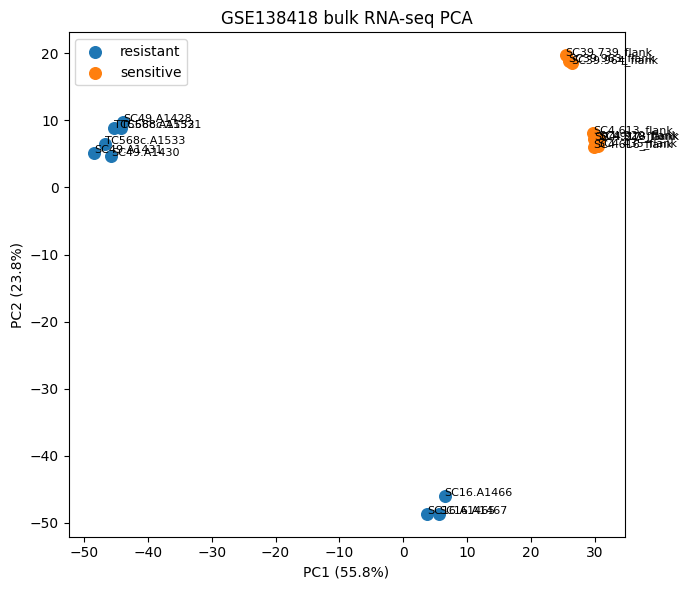

In [18]:
# =========================
# Step A8. PCA using highly variable genes
# =========================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# high variance genes
top_n = min(2000, log_cpm.shape[0])
top_var_genes = log_cpm.var(axis=1).sort_values(ascending=False).head(top_n).index

X = log_cpm.loc[top_var_genes].T
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_coords,
    index=X.index,
    columns=["PC1", "PC2"]
).join(meta)

print("Explained variance:", pca.explained_variance_ratio_)

plt.figure(figsize=(7, 6))
for group, df in pca_df.groupby("response_clean"):
    plt.scatter(df["PC1"], df["PC2"], label=group, s=70)

for idx, row in pca_df.iterrows():
    plt.text(row["PC1"], row["PC2"], row["title"], fontsize=8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("GSE138418 bulk RNA-seq PCA")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "GSE138418_PCA.png", dpi=200)
plt.show()

In [20]:
# =========================
# Step A9. Define SCLC-related signatures
# =========================

SIGNATURES = {
    # Neuroendocrine / SCLC-A-like
    "SCLC_A_NE": [
        "ASCL1", "DLL3", "INSM1", "CHGA", "SYP", "NCAM1", "BCL2", "MYCL"
    ],

    # NEUROD1 / MYC-like
    "SCLC_N_MYC": [
        "NEUROD1", "MYC", "AURKA", "AURKB", "HES6"
    ],

    # POU2F3 / tuft-like
    "SCLC_P": [
        "POU2F3", "TRPM5", "SOX9", "ASCL2"
    ],

    # Inflamed / IFN / antigen presentation
    "SCLC_I_Inflamed": [
        "HLA-A", "HLA-B", "HLA-C", "B2M", "STAT1", "IRF1",
        "CXCL9", "CXCL10", "CD274", "PDCD1LG2", "IFNG"
    ],

    # EMT / non-NE / invasive-like
    "EMT_non_NE": [
        "VIM", "AXL", "ZEB1", "ZEB2", "TWIST1", "CDH2", "FN1", "ITGA5", "ITGB1"
    ],

    # Epithelial / CTC capture-related
    "Epithelial": [
        "EPCAM", "CDH1", "KRT8", "KRT18", "KRT19", "CLDN3", "CLDN4"
    ],

    # MYC / proliferation / E2F / G2M
    "MYC_E2F_G2M": [
        "MYC", "E2F1", "E2F2", "MKI67", "TOP2A", "CDK1",
        "CCNB1", "PCNA", "MCM2", "MCM4", "MCM6"
    ],

    # DNA damage repair / platinum-topoisomerase related
    "DNA_repair_DDR": [
        "PARP1", "CHEK1", "TOP1", "TOP2A", "TOP2B",
        "SLFN11", "BRCA1", "RAD51", "MSH2", "MSH6"
    ],

    # Therapeutic target antigens
    "Target_antigens": [
        "DLL3", "CLDN3", "CD276", "SEZ6", "EPCAM", "NCAM1"
    ],

    # Your project axis
    "CLDN3_B7H3_axis": [
        "CLDN3", "CD276"
    ],
}

In [21]:
# =========================
# Step A10. Module score function
# =========================

def zscore_genes(expr):
    """
    expr: gene x sample log expression matrix
    gene별로 sample across z-score.
    """
    mean = expr.mean(axis=1)
    std = expr.std(axis=1).replace(0, np.nan)
    return expr.sub(mean, axis=0).div(std, axis=0)


def module_scores(expr_log, signatures):
    """
    z-scored expression에서 signature별 평균 score 계산.
    """
    z = zscore_genes(expr_log)
    score_df = pd.DataFrame(index=expr_log.columns)
    used = {}
    missing = {}

    for name, genes in signatures.items():
        valid = [g for g in genes if g in z.index]
        miss = [g for g in genes if g not in z.index]

        used[name] = valid
        missing[name] = miss

        if len(valid) == 0:
            score_df[name] = np.nan
        else:
            score_df[name] = z.loc[valid].mean(axis=0)

    return score_df, used, missing


scores, used_genes, missing_genes = module_scores(log_cpm, SIGNATURES)

scores_meta = scores.join(meta)
display(scores_meta.head())

# 어떤 gene이 실제 사용됐는지 확인
for sig, genes in used_genes.items():
    print(f"{sig}: {len(genes)} used -> {genes}")

,SCLC_A_NE,SCLC_N_MYC,SCLC_P,SCLC_I_Inflamed,EMT_non_NE,Epithelial,MYC_E2F_G2M,DNA_repair_DDR,Target_antigens,CLDN3_B7H3_axis,title,source_name,organism,disease state,tissue,sample type,treatment,platinum response,response_clean,treatment_clean
GSM4107777,0.300868,-0.252037,0.158323,0.032988,-0.255983,0.845692,-0.323939,-0.357449,0.745372,1.012790,SC4.435_flank,MDA-SC4,Homo sapiens,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive,sensitive,untreated
GSM4107778,0.501725,0.002676,-0.059339,0.082894,-0.357576,0.705409,-0.415552,-0.343795,0.827706,1.058944,SC4.613_flank,MDA-SC4,Homo sapiens,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive,sensitive,untreated
GSM4107779,0.294663,0.108334,0.359899,-0.113970,-0.138219,0.863695,-0.228440,-0.278899,0.701422,1.047607,SC4.616_flank,MDA-SC4,Homo sapiens,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive,sensitive,untreated
GSM4107780,0.128273,-0.840986,-0.134545,-0.584390,-0.198404,0.800295,-0.745471,-0.043250,0.496694,0.808078,SC4.917_flank,MDA-SC4,Homo sapiens,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive,sensitive,untreated
GSM4107781,0.320097,0.402800,0.788996,-0.201515,-0.425260,0.851905,-0.500884,-0.736020,0.593631,1.015480,SC4.918_flank,MDA-SC4,Homo sapiens,Small cell lung cancer (SCLC),flank,CDX,untreated,sensitive,sensitive,untreated


SCLC_A_NE: 8 used -> ['ASCL1', 'DLL3', 'INSM1', 'CHGA', 'SYP', 'NCAM1', 'BCL2', 'MYCL']
SCLC_N_MYC: 5 used -> ['NEUROD1', 'MYC', 'AURKA', 'AURKB', 'HES6']
SCLC_P: 4 used -> ['POU2F3', 'TRPM5', 'SOX9', 'ASCL2']
SCLC_I_Inflamed: 8 used -> ['HLA-A', 'HLA-B', 'HLA-C', 'B2M', 'STAT1', 'IRF1', 'CXCL10', 'CD274']
EMT_non_NE: 9 used -> ['VIM', 'AXL', 'ZEB1', 'ZEB2', 'TWIST1', 'CDH2', 'FN1', 'ITGA5', 'ITGB1']
Epithelial: 7 used -> ['EPCAM', 'CDH1', 'KRT8', 'KRT18', 'KRT19', 'CLDN3', 'CLDN4']
MYC_E2F_G2M: 11 used -> ['MYC', 'E2F1', 'E2F2', 'MKI67', 'TOP2A', 'CDK1', 'CCNB1', 'PCNA', 'MCM2', 'MCM4', 'MCM6']
DNA_repair_DDR: 10 used -> ['PARP1', 'CHEK1', 'TOP1', 'TOP2A', 'TOP2B', 'SLFN11', 'BRCA1', 'RAD51', 'MSH2', 'MSH6']
Target_antigens: 6 used -> ['DLL3', 'CLDN3', 'CD276', 'SEZ6', 'EPCAM', 'NCAM1']
CLDN3_B7H3_axis: 2 used -> ['CLDN3', 'CD276']


In [22]:
# =========================
# Step A11. Create exploratory relapse-like score
# =========================

# 이건 published validated score가 아니라, 탐색적 composite score.
# resistant-like biology를 보기 위한 working score로만 사용.

scores_meta["Relapse_like_score"] = (
    scores_meta["MYC_E2F_G2M"]
    + scores_meta["EMT_non_NE"]
    + scores_meta["DNA_repair_DDR"]
    - scores_meta["SCLC_A_NE"]
)

save_table(scores_meta, "GSE138418_signature_scores.csv")

display(scores_meta[["title", "response_clean"] + list(SIGNATURES.keys()) + ["Relapse_like_score"]])

[saved] /content/drive/MyDrive/SCLC_Stewart_GSE138474/results/tables/GSE138418_signature_scores.csv


,title,response_clean,SCLC_A_NE,SCLC_N_MYC,SCLC_P,SCLC_I_Inflamed,EMT_non_NE,Epithelial,MYC_E2F_G2M,DNA_repair_DDR,Target_antigens,CLDN3_B7H3_axis,Relapse_like_score
GSM4107777,SC4.435_flank,sensitive,0.300868,-0.252037,0.158323,0.032988,-0.255983,0.845692,-0.323939,-0.357449,0.745372,1.012790,-1.238239
GSM4107778,SC4.613_flank,sensitive,0.501725,0.002676,-0.059339,0.082894,-0.357576,0.705409,-0.415552,-0.343795,0.827706,1.058944,-1.618649
GSM4107779,SC4.616_flank,sensitive,0.294663,0.108334,0.359899,-0.113970,-0.138219,0.863695,-0.228440,-0.278899,0.701422,1.047607,-0.940222
GSM4107780,SC4.917_flank,sensitive,0.128273,-0.840986,-0.134545,-0.584390,-0.198404,0.800295,-0.745471,-0.043250,0.496694,0.808078,-1.115399
GSM4107781,SC4.918_flank,sensitive,0.320097,0.402800,0.788996,-0.201515,-0.425260,0.851905,-0.500884,-0.736020,0.593631,1.015480,-1.982262
GSM4107782,SC4.920_flank,sensitive,0.389546,0.170675,0.259845,-0.003554,-0.030122,1.000595,-0.760425,-0.844560,0.991031,1.152786,-2.024653
GSM4107774,SC39.739_flank,sensitive,0.195950,-0.070172,0.051150,-0.160685,-0.098520,-0.466107,0.624704,-0.079894,0.744348,0.376023,0.250340
GSM4107775,SC39.963_flank,sensitive,0.367648,-0.184015,0.257773,0.148903,-0.544244,0.320117,0.084016,-0.351613,0.806188,0.682171,-1.179489
GSM4107776,SC39.964_flank,sensitive,0.261896,-0.158409,0.206830,0.055586,-0.311693,0.324689,0.158663,-0.410685,0.779821,0.621997,-0.825611
GSM4107771,SC16.A1465,resistant,-0.825471,-1.784235,-0.620809,0.995591,-0.315380,-0.611580,-0.947497,-0.732802,-0.874601,-1.128899,-1.170209


In [23]:
# =========================
# Step A12. Statistical comparison: resistant vs sensitive
# =========================

def compare_two_groups(df, score_cols, group_col="response_clean", group_a="resistant", group_b="sensitive"):
    rows = []

    for col in score_cols:
        a = df.loc[df[group_col] == group_a, col].dropna()
        b = df.loc[df[group_col] == group_b, col].dropna()

        if len(a) < 2 or len(b) < 2:
            rows.append({
                "signature": col,
                "n_resistant": len(a),
                "n_sensitive": len(b),
                "mean_resistant": np.nan,
                "mean_sensitive": np.nan,
                "delta_resistant_minus_sensitive": np.nan,
                "p_mannwhitney": np.nan
            })
            continue

        stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        rows.append({
            "signature": col,
            "n_resistant": len(a),
            "n_sensitive": len(b),
            "mean_resistant": a.mean(),
            "mean_sensitive": b.mean(),
            "delta_resistant_minus_sensitive": a.mean() - b.mean(),
            "p_mannwhitney": p
        })

    out = pd.DataFrame(rows)
    out["q_bh"] = multipletests(out["p_mannwhitney"].fillna(1), method="fdr_bh")[1]
    return out.sort_values("p_mannwhitney")


score_cols = list(SIGNATURES.keys()) + ["Relapse_like_score"]

sig_stats = compare_two_groups(scores_meta, score_cols)
display(sig_stats)

save_table(sig_stats, "GSE138418_signature_resistant_vs_sensitive_stats.csv")

,signature,n_resistant,n_sensitive,mean_resistant,mean_sensitive,delta_resistant_minus_sensitive,p_mannwhitney,q_bh
9,CLDN3_B7H3_axis,9,9,-0.863986,0.863986,-1.727972,0.000412,0.002103
8,Target_antigens,9,9,-0.742913,0.742913,-1.485825,0.000412,0.002103
0,SCLC_A_NE,9,9,-0.306741,0.306741,-0.613481,0.000574,0.002103
5,Epithelial,9,9,-0.582921,0.582921,-1.165842,0.003569,0.009814
10,Relapse_like_score,9,9,1.186020,-1.186020,2.372041,0.008071,0.017757
2,SCLC_P,9,9,-0.209881,0.209881,-0.419763,0.013419,0.024601
7,DNA_repair_DDR,9,9,0.382907,-0.382907,0.765815,0.034069,0.053537
6,MYC_E2F_G2M,9,9,0.234148,-0.234148,0.468295,0.063690,0.087573
4,EMT_non_NE,9,9,0.262225,-0.262225,0.524449,0.157704,0.192750
1,SCLC_N_MYC,9,9,0.091237,-0.091237,0.182474,0.216373,0.238010


[saved] /content/drive/MyDrive/SCLC_Stewart_GSE138474/results/tables/GSE138418_signature_resistant_vs_sensitive_stats.csv


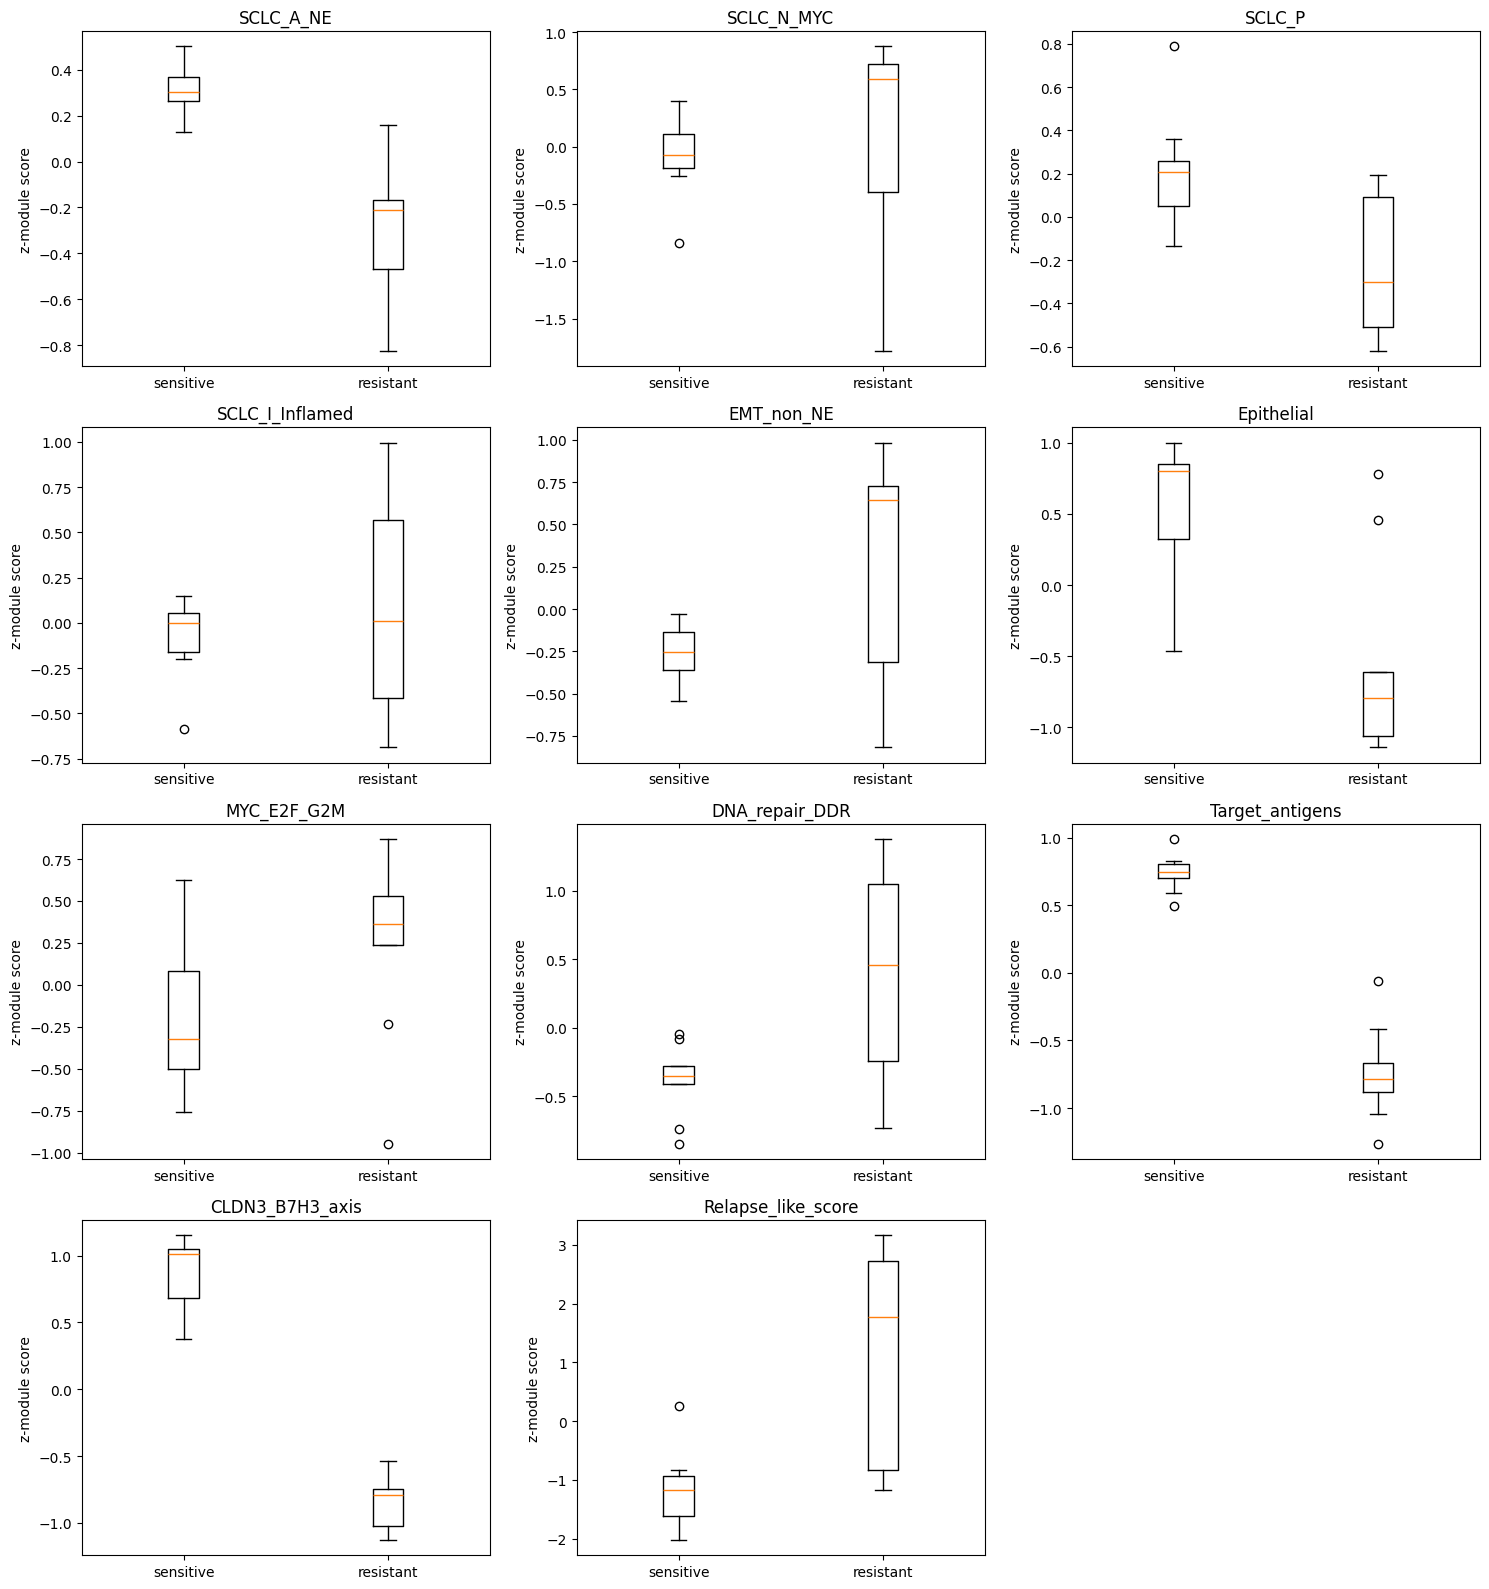

In [24]:
# =========================
# Step A13. Boxplots for signature scores
# =========================

plot_cols = score_cols
n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    data = [
        scores_meta.loc[scores_meta["response_clean"] == "sensitive", col].dropna(),
        scores_meta.loc[scores_meta["response_clean"] == "resistant", col].dropna()
    ]
    ax.boxplot(data, labels=["sensitive", "resistant"])
    ax.set_title(col)
    ax.set_ylabel("z-module score")

for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "GSE138418_signature_boxplots.png", dpi=200)
plt.show()

valid: ['DLL3', 'CLDN3', 'CD276', 'SEZ6', 'EPCAM', 'NCAM1', 'ASCL1', 'NEUROD1', 'POU2F3', 'MYC', 'MYCL', 'MYCN', 'VIM', 'AXL', 'ZEB1', 'SLFN11', 'PARP1', 'CHEK1', 'AURKA', 'AURKB']
missing: []


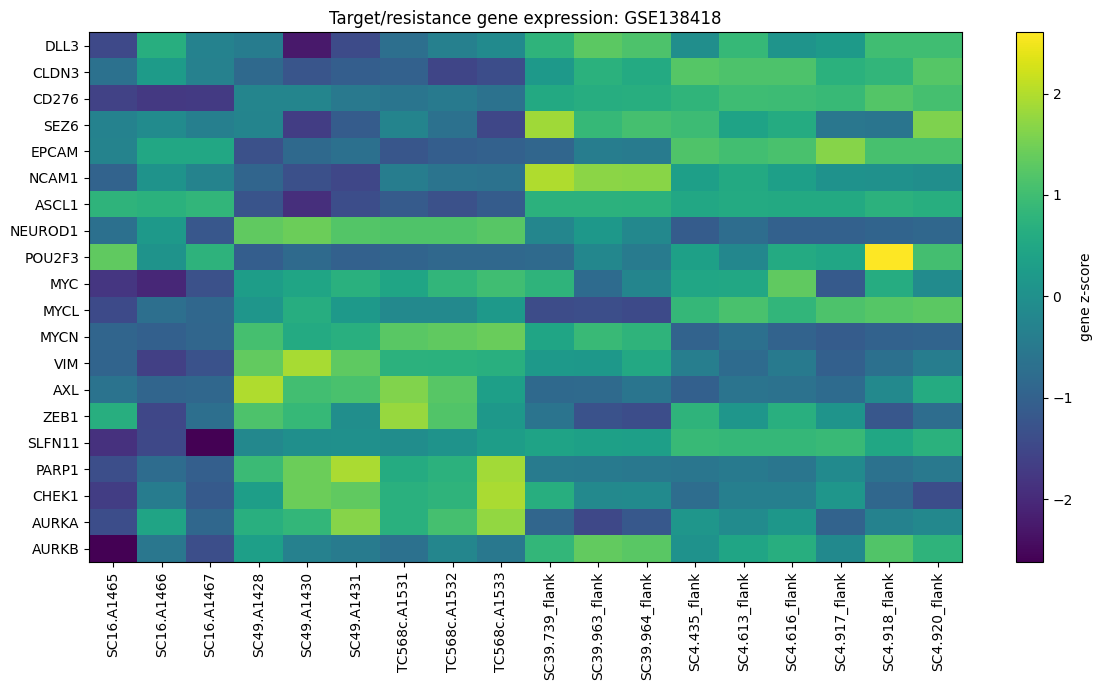

In [25]:
# =========================
# Step A14. Target gene expression heatmap
# =========================

target_genes = [
    "DLL3", "CLDN3", "CD276", "SEZ6", "EPCAM", "NCAM1",
    "ASCL1", "NEUROD1", "POU2F3", "MYC", "MYCL", "MYCN",
    "VIM", "AXL", "ZEB1", "SLFN11", "PARP1", "CHEK1", "AURKA", "AURKB"
]

valid_targets = [g for g in target_genes if g in log_cpm.index]
missing_targets = [g for g in target_genes if g not in log_cpm.index]

print("valid:", valid_targets)
print("missing:", missing_targets)

sample_order = (
    meta.sort_values(["response_clean", "title"])
    .index
    .intersection(log_cpm.columns)
)

heat = zscore_genes(log_cpm).loc[valid_targets, sample_order]

plt.figure(figsize=(12, max(5, 0.35 * len(valid_targets))))
plt.imshow(heat.values, aspect="auto")
plt.colorbar(label="gene z-score")
plt.yticks(range(len(valid_targets)), valid_targets)
plt.xticks(range(len(sample_order)), meta.loc[sample_order, "title"], rotation=90)
plt.title("Target/resistance gene expression: GSE138418")
plt.tight_layout()
plt.savefig(FIG_DIR / "GSE138418_target_gene_heatmap.png", dpi=200)
plt.show()

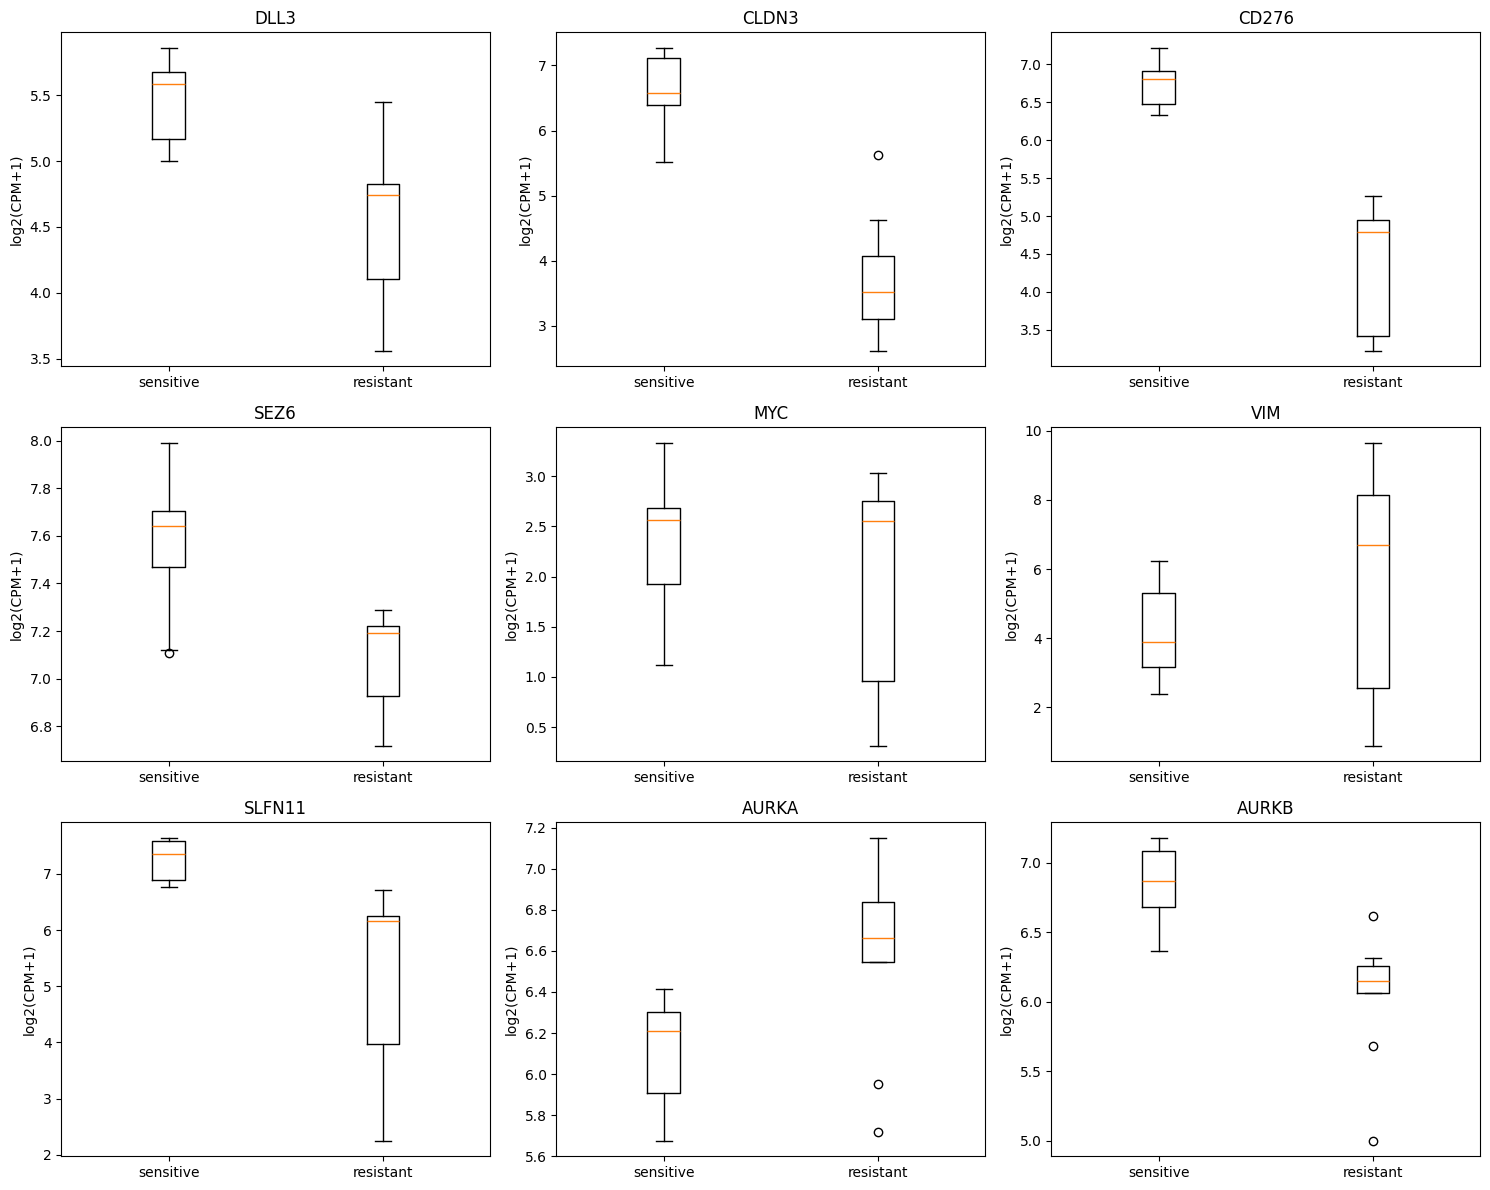

In [26]:
# =========================
# Step A15. Single gene boxplots
# =========================

genes_to_plot = ["DLL3", "CLDN3", "CD276", "SEZ6", "MYC", "VIM", "SLFN11", "AURKA", "AURKB"]
genes_to_plot = [g for g in genes_to_plot if g in log_cpm.index]

n_cols = 3
n_rows = int(np.ceil(len(genes_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

expr_meta = log_cpm.T.join(meta)

for ax, gene in zip(axes, genes_to_plot):
    data = [
        expr_meta.loc[expr_meta["response_clean"] == "sensitive", gene].dropna(),
        expr_meta.loc[expr_meta["response_clean"] == "resistant", gene].dropna()
    ]
    ax.boxplot(data, labels=["sensitive", "resistant"])
    ax.set_title(gene)
    ax.set_ylabel("log2(CPM+1)")

for ax in axes[len(genes_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "GSE138418_target_gene_boxplots.png", dpi=200)
plt.show()

In [27]:
# =========================
# Step A16. Simple DE: resistant vs sensitive
# =========================

def simple_de_logcpm(expr_log, meta, group_col="response_clean", case="resistant", control="sensitive"):
    case_samples = meta.index[meta[group_col] == case].intersection(expr_log.columns)
    ctrl_samples = meta.index[meta[group_col] == control].intersection(expr_log.columns)

    rows = []
    for gene in tqdm(expr_log.index):
        x = expr_log.loc[gene, case_samples].dropna()
        y = expr_log.loc[gene, ctrl_samples].dropna()

        if len(x) < 2 or len(y) < 2:
            continue

        t, p = stats.ttest_ind(x, y, equal_var=False)
        log2fc = x.mean() - y.mean()

        rows.append({
            "gene": gene,
            "mean_case": x.mean(),
            "mean_control": y.mean(),
            "log2FC_case_minus_control": log2fc,
            "t_stat": t,
            "p_value": p
        })

    de = pd.DataFrame(rows)
    de["q_bh"] = multipletests(de["p_value"].fillna(1), method="fdr_bh")[1]
    de = de.sort_values("p_value")
    return de


de418 = simple_de_logcpm(log_cpm, meta)
display(de418.head(20))

save_table(de418.set_index("gene"), "GSE138418_simple_DE_resistant_vs_sensitive.csv")

  0%|          | 0/22286 [00:00<?, ?it/s]

,gene,mean_case,mean_control,log2FC_case_minus_control,t_stat,p_value,q_bh
21667,ZIC1,0.079903,4.229869,-4.149966,-71.401451,3.059545e-21,6.818501e-17
11279,NOVA2,0.281729,4.703998,-4.422270,-49.898327,8.982415e-19,1.000911e-14
1839,ATP6V0C,0.261969,5.296294,-5.034325,-44.010921,4.042768e-18,3.003237e-14
10645,MTND1P23,0.459538,10.193213,-9.733675,-50.412234,5.550992e-18,3.092735e-14
21206,WASH4P,0.115935,5.284804,-5.168869,-63.100021,5.257193e-17,2.153681e-13
7145,GPR75-ASB3,0.046581,3.859381,-3.812801,-60.133718,5.798297e-17,2.153681e-13
21681,ZMAT1,0.543484,5.797225,-5.253741,-34.599945,2.151640e-16,6.850208e-13
2346,C16orf45,0.275325,5.427819,-5.152494,-39.861212,1.043804e-15,2.907778e-12
6801,GDAP1L1,0.227428,4.119579,-3.892151,-32.041182,1.458786e-15,3.612278e-12
10648,MTND4P12,0.795952,10.981167,-10.185215,-39.116961,2.425476e-15,4.955691e-12


[saved] /content/drive/MyDrive/SCLC_Stewart_GSE138474/results/tables/GSE138418_simple_DE_resistant_vs_sensitive.csv


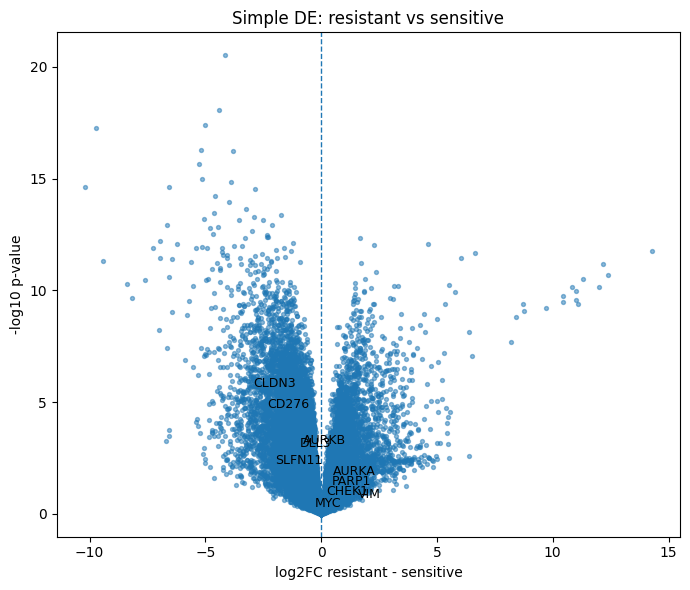

In [28]:
# =========================
# Step A17. Volcano plot
# =========================

de_plot = de418.copy()
de_plot["neglog10p"] = -np.log10(de_plot["p_value"].clip(lower=1e-300))

plt.figure(figsize=(7, 6))
plt.scatter(
    de_plot["log2FC_case_minus_control"],
    de_plot["neglog10p"],
    s=8,
    alpha=0.5
)

# 관심 gene label
for gene in ["MYC", "DLL3", "CLDN3", "CD276", "VIM", "SLFN11", "AURKA", "AURKB", "PARP1", "CHEK1"]:
    tmp = de_plot[de_plot["gene"] == gene]
    if tmp.shape[0] > 0:
        x = tmp["log2FC_case_minus_control"].iloc[0]
        y = tmp["neglog10p"].iloc[0]
        plt.text(x, y, gene, fontsize=9)

plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("log2FC resistant - sensitive")
plt.ylabel("-log10 p-value")
plt.title("Simple DE: resistant vs sensitive")
plt.tight_layout()
plt.savefig(FIG_DIR / "GSE138418_simple_DE_volcano.png", dpi=200)
plt.show()

In [29]:
# =========================
# Step A18. GSEA prerank
# =========================

# ranking: t statistic 기준
rnk = de418[["gene", "t_stat"]].dropna()
rnk = rnk.sort_values("t_stat", ascending=False)

gsea_outdir = RESULTS_DIR / "GSE138418_GSEA_Hallmark"
gsea_outdir.mkdir(exist_ok=True, parents=True)

pre_res = gp.prerank(
    rnk=rnk,
    gene_sets="MSigDB_Hallmark_2020",
    outdir=str(gsea_outdir),
    min_size=5,
    max_size=500,
    permutation_num=1000,
    seed=42,
    verbose=True
)

gsea_res = pre_res.res2d
display(gsea_res.head(20))

gsea_res.to_csv(TABLE_DIR / "GSE138418_GSEA_Hallmark_prerank.csv", index=False)

2026-07-01 07:35:57,750 [INFO] Parsing data files for GSEA.............................
2026-07-01 07:35:58,227 [INFO] Downloading and generating Enrichr library gene sets......
2026-07-01 07:35:58,334 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=5
2026-07-01 07:35:58,340 [INFO] 0050 gene_sets used for further statistical testing.....
2026-07-01 07:35:58,342 [INFO] Start to run GSEA...Might take a while..................
2026-07-01 07:36:16,864 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Myc Targets V1,0.356328,1.856573,0.000000,0.017323,0.005,67/194,16.41%,DEK;KPNB1;AP3S1;EIF3J;PSMD1;SNRPB2;DDX18;RSL1D...
1,prerank,E2F Targets,0.349846,1.768493,0.000000,0.019055,0.011,65/195,17.91%,PSIP1;DEK;DIAPH3;HMGB2;SMC3;PDS5B;SPC25;DUT;SM...
2,prerank,G2-M Checkpoint,0.329559,1.626629,0.000000,0.038110,0.032,57/189,15.73%,PRPF4B;TOP1;KPNB1;CASP8AP2;NUSAP1;SLC12A2;PDS5...
3,prerank,Adipogenesis,-0.402451,-1.426366,0.013347,0.909514,0.652,48/180,15.52%,UQCR11;BCKDHA;SLC25A10;EPHX2;BAZ2A;COX6A1;ESRR...
4,prerank,Hedgehog Signaling,-0.459481,-1.324654,0.131227,1.000000,0.930,11/34,20.78%,MYH9;VLDLR;NKX6-1;CRMP1;NRCAM;DPYSL2;PML;THY1;...
5,prerank,Bile Acid Metabolism,-0.377763,-1.280473,0.102784,1.000000,0.973,23/98,16.31%,PEX26;ABCA3;ALDH8A1;CYP27A1;EPHX2;BCAR3;PXMP2;...
6,prerank,Reactive Oxygen Species Pathway,-0.414863,-1.280251,0.148191,0.853086,0.973,22/46,34.51%,TXNRD2;PFKP;ABCC1;SRXN1;SOD2;G6PD;MBP;SBNO2;PR...
7,prerank,Apical Junction,-0.347393,-1.231535,0.102591,0.996634,0.992,54/181,24.31%,PCDH1;MYH9;CD99;ADAM15;IKBKG;ZYX;GNAI2;RHOF;KC...
8,prerank,Xenobiotic Metabolism,-0.340547,-1.203620,0.131880,1.000000,0.999,71/162,35.31%,ASL;XDH;CYP27A1;NINJ1;FBP1;TMBIM6;TMEM176B;NDR...
9,prerank,Oxidative Phosphorylation,-0.328436,-1.177847,0.154629,1.000000,0.999,34/184,20.37%,SLC25A6;ATP6V0C;NDUFA7;POLR2F;NDUFB8;UQCR11;BC...


In [33]:
# =========================
# Step A7-fix. 라인(line) 정보 추가
# =========================
meta["line"] = meta["source_name"].astype(str)

line_summary = (
    meta.groupby(["line", "response_clean"])
    .size()
    .reset_index(name="n_replicates")
)
print("=== 라인별 replicate 구조 ===")
display(line_summary)

n_lines_per_group = meta.drop_duplicates("line").groupby("response_clean")["line"].count()
print("\n=== 그룹별 독립 라인 수 (샘플 수 아님!) ===")
print(n_lines_per_group)

save_table(line_summary, "GSE138418_line_replicate_structure.csv")

=== 라인별 replicate 구조 ===


,line,response_clean,n_replicates
0,MDA-PDX49,resistant,3
1,MDA-SC16,resistant,3
2,MDA-SC39,sensitive,3
3,MDA-SC4,sensitive,6
4,MDA-SC49,resistant,3



=== 그룹별 독립 라인 수 (샘플 수 아님!) ===
response_clean
resistant    3
sensitive    2
Name: line, dtype: int64
[saved] /content/drive/MyDrive/SCLC_Stewart_GSE138474/results/tables/GSE138418_line_replicate_structure.csv


Explained variance: [0.55813181 0.23846768]


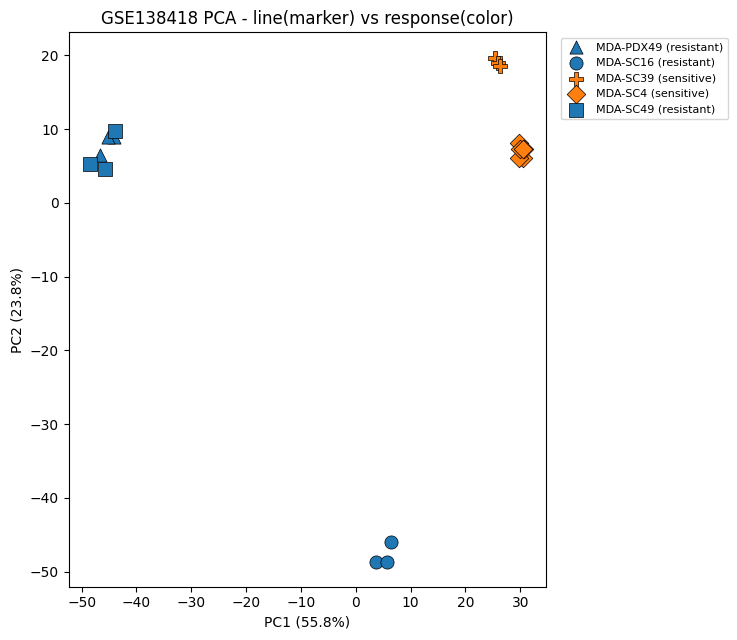

In [34]:
# =========================
# Step A8-fix. PCA - line 정보 함께 표시
# =========================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

top_n = min(2000, log_cpm.shape[0])
top_var_genes = log_cpm.var(axis=1).sort_values(ascending=False).head(top_n).index
X = log_cpm.loc[top_var_genes].T
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_coords, index=X.index, columns=["PC1", "PC2"]).join(meta)

print("Explained variance:", pca.explained_variance_ratio_)

markers = {"MDA-SC16": "o", "MDA-SC49": "s", "MDA-PDX49": "^",
           "MDA-SC4": "D", "MDA-SC39": "P"}
colors = {"resistant": "tab:blue", "sensitive": "tab:orange"}

plt.figure(figsize=(7.5, 6.5))
for line, df_line in pca_df.groupby("line"):
    resp = df_line["response_clean"].iloc[0]
    plt.scatter(
        df_line["PC1"], df_line["PC2"],
        marker=markers.get(line, "x"),
        color=colors.get(resp, "gray"),
        s=90, edgecolor="black", linewidth=0.5,
        label=f"{line} ({resp})"
    )
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("GSE138418 PCA - line(marker) vs response(color)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "GSE138418_PCA_by_line.png", dpi=200, bbox_inches="tight")
plt.show()

In [37]:
# =========================
# Step A12-fix. 시그니처 스코어 통계 - 라인 단위로 재계산
# =========================

# scores_meta에 line 컬럼이 없으므로 다시 추가 (meta는 이미 line을 가지고 있음)
scores_meta["line"] = meta.loc[scores_meta.index, "line"]

def compare_two_groups_by_line(df, score_cols, line_col="line",
                                 group_col="response_clean",
                                 group_a="resistant", group_b="sensitive"):
    line_level = df.groupby(line_col)[score_cols + [group_col]].agg(
        {**{c: "mean" for c in score_cols}, group_col: "first"}
    )

    rows = []
    for col in score_cols:
        a = line_level.loc[line_level[group_col] == group_a, col].dropna()
        b = line_level.loc[line_level[group_col] == group_b, col].dropna()

        row = {
            "signature": col,
            "n_lines_resistant": len(a),
            "n_lines_sensitive": len(b),
            "mean_resistant": a.mean() if len(a) else np.nan,
            "mean_sensitive": b.mean() if len(b) else np.nan,
            "delta_resistant_minus_sensitive": (a.mean() - b.mean()) if len(a) and len(b) else np.nan,
        }

        if len(a) >= 2 and len(b) >= 2:
            stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
            row["p_mannwhitney_line_level"] = p
        else:
            row["p_mannwhitney_line_level"] = np.nan

        rows.append(row)

    out = pd.DataFrame(rows)
    out["q_bh"] = multipletests(out["p_mannwhitney_line_level"].fillna(1), method="fdr_bh")[1]
    return out.sort_values("p_mannwhitney_line_level"), line_level


score_cols = list(SIGNATURES.keys()) + ["Relapse_like_score"]
sig_stats_line, line_level_scores = compare_two_groups_by_line(scores_meta, score_cols)

print("=== 라인 단위 통계 (실제 독립 n=3 vs n=2) ===")
print("주의: 이 n으로는 어떤 검정도 통계적 검정력이 거의 없습니다.")
display(sig_stats_line)

save_table(sig_stats_line, "GSE138418_signature_stats_LINE_LEVEL.csv")
save_table(line_level_scores, "GSE138418_signature_scores_by_line.csv")

comparison = sig_stats.set_index("signature")[["p_mannwhitney"]].rename(
    columns={"p_mannwhitney": "p_SAMPLE_level_INFLATED"}
).join(
    sig_stats_line.set_index("signature")[["p_mannwhitney_line_level"]]
)
print("\n=== Sample-level(부풀려진 n) vs Line-level(진짜 n) p-value 비교 ===")
display(comparison)
save_table(comparison, "GSE138418_pvalue_inflation_comparison.csv")

=== 라인 단위 통계 (실제 독립 n=3 vs n=2) ===
주의: 이 n으로는 어떤 검정도 통계적 검정력이 거의 없습니다.


,signature,n_lines_resistant,n_lines_sensitive,mean_resistant,mean_sensitive,delta_resistant_minus_sensitive,p_mannwhitney_line_level,q_bh
0,SCLC_A_NE,3,2,-0.306741,0.298847,-0.605587,0.2,0.550000
2,SCLC_P,3,2,-0.209881,0.200390,-0.410272,0.2,0.550000
9,CLDN3_B7H3_axis,3,2,-0.863986,0.788006,-1.651992,0.2,0.550000
8,Target_antigens,3,2,-0.742913,0.751381,-1.494293,0.2,0.550000
6,MYC_E2F_G2M,3,2,0.234148,-0.103329,0.337477,0.4,0.628571
10,Relapse_like_score,3,2,1.186020,-1.035745,2.221766,0.4,0.628571
5,Epithelial,3,2,-0.582921,0.452082,-1.035004,0.4,0.628571
4,EMT_non_NE,3,2,0.262225,-0.276207,0.538431,0.8,0.880000
1,SCLC_N_MYC,3,2,0.091237,-0.102811,0.194048,0.8,0.880000
7,DNA_repair_DDR,3,2,0.382907,-0.357363,0.740271,0.8,0.880000


[saved] /content/drive/MyDrive/SCLC_Stewart_GSE138474/results/tables/GSE138418_signature_stats_LINE_LEVEL.csv
[saved] /content/drive/MyDrive/SCLC_Stewart_GSE138474/results/tables/GSE138418_signature_scores_by_line.csv

=== Sample-level(부풀려진 n) vs Line-level(진짜 n) p-value 비교 ===


,p_SAMPLE_level_INFLATED,p_mannwhitney_line_level
signature,,
CLDN3_B7H3_axis,0.000412,0.2
Target_antigens,0.000412,0.2
SCLC_A_NE,0.000574,0.2
Epithelial,0.003569,0.4
Relapse_like_score,0.008071,0.4
SCLC_P,0.013419,0.2
DNA_repair_DDR,0.034069,0.8
MYC_E2F_G2M,0.063690,0.4
EMT_non_NE,0.157704,0.8


[saved] /content/drive/MyDrive/SCLC_Stewart_GSE138474/results/tables/GSE138418_pvalue_inflation_comparison.csv


In [38]:
# =========================
# Step A16-fix. DE 분석 - 라인 단위 pseudobulk
# =========================
def simple_de_by_line(expr_log, meta, line_col="line", group_col="response_clean",
                        case="resistant", control="sensitive"):
    line_expr = expr_log.T.join(meta[[line_col, group_col]]).groupby(line_col).mean(numeric_only=True).T
    line_group = meta.drop_duplicates(line_col).set_index(line_col)[group_col]

    case_lines = line_group.index[line_group == case]
    ctrl_lines = line_group.index[line_group == control]

    print(f"DE 검정 단위: {case} n={len(case_lines)} 라인, {control} n={len(ctrl_lines)} 라인")

    rows = []
    for gene in tqdm(line_expr.index):
        x = line_expr.loc[gene, case_lines].dropna()
        y = line_expr.loc[gene, ctrl_lines].dropna()

        if len(x) < 2 or len(y) < 2:
            continue

        t, p = stats.ttest_ind(x, y, equal_var=False)
        rows.append({
            "gene": gene,
            "mean_case_lineavg": x.mean(),
            "mean_control_lineavg": y.mean(),
            "log2FC_case_minus_control": x.mean() - y.mean(),
            "t_stat": t,
            "p_value": p,
        })

    de = pd.DataFrame(rows)
    de["q_bh"] = multipletests(de["p_value"].fillna(1), method="fdr_bh")[1]
    de = de.sort_values("p_value")
    return de

de418_line = simple_de_by_line(log_cpm, meta)
print("\n=== 라인 단위 DE 상위 결과 ===")
display(de418_line.head(20))
save_table(de418_line.set_index("gene"), "GSE138418_simple_DE_LINE_LEVEL_resistant_vs_sensitive.csv")

print("\n=== 원본(샘플 단위, n=9 vs 9) 상위 유전자가 라인 단위에서는? ===")
top_sample_level_genes = de418.head(20)["gene"].tolist()
check = de418_line.set_index("gene").reindex(top_sample_level_genes)[
    ["log2FC_case_minus_control", "p_value", "q_bh"]
]
check.columns = ["log2FC_line_level", "p_line_level", "q_line_level"]
display(check)

DE 검정 단위: resistant n=3 라인, sensitive n=2 라인


  0%|          | 0/22286 [00:00<?, ?it/s]


=== 라인 단위 DE 상위 결과 ===


,gene,mean_case_lineavg,mean_control_lineavg,log2FC_case_minus_control,t_stat,p_value,q_bh
14583,RP11-158M2.5,0.193486,1.158156,-0.964670,-61.229913,0.000010,0.087631
1281,ANO1,0.236296,3.236296,-3.000000,-58.475656,0.000012,0.087631
13665,RGPD5,0.604977,1.604204,-0.999227,-56.575624,0.000012,0.087631
6157,FAM74A3,0.000000,1.021591,-1.021591,-30385.380541,0.000021,0.087631
6646,FZD5,3.122829,4.757263,-1.634434,-42.840385,0.000033,0.087631
14881,RP11-24C3.2,0.220267,1.397631,-1.177364,-49.878922,0.000035,0.087631
3492,CICP14,0.005702,0.438747,-0.433045,-54.184992,0.000035,0.087631
10616,MTFP1,0.631486,2.836232,-2.204747,-48.590669,0.000039,0.087631
10645,MTND1P23,0.459538,10.225743,-9.766206,-45.738252,0.000041,0.087631
9484,LRRC26,0.101699,1.670498,-1.568799,-37.419294,0.000043,0.087631


[saved] /content/drive/MyDrive/SCLC_Stewart_GSE138474/results/tables/GSE138418_simple_DE_LINE_LEVEL_resistant_vs_sensitive.csv

=== 원본(샘플 단위, n=9 vs 9) 상위 유전자가 라인 단위에서는? ===


,log2FC_line_level,p_line_level,q_line_level
gene,,,
ZIC1,-4.167842,0.000043,0.087631
NOVA2,-4.420781,0.000096,0.120378
ATP6V0C,-5.109410,0.007540,0.256304
MTND1P23,-9.766206,0.000041,0.087631
WASH4P,-5.121910,0.011729,0.283627
GPR75-ASB3,-3.855144,0.012842,0.284772
ZMAT1,-5.292567,0.000109,0.120378
C16orf45,-5.119863,0.000071,0.120378
GDAP1L1,-3.936245,0.000956,0.172502


In [39]:
# =========================
# Step A18-fix. GSEA prerank - 라인 단위 통계로 재계산
# =========================
rnk_line = de418_line[["gene", "t_stat"]].dropna().sort_values("t_stat", ascending=False)

gsea_outdir_line = RESULTS_DIR / "GSE138418_GSEA_Hallmark_LINE_LEVEL"
gsea_outdir_line.mkdir(exist_ok=True, parents=True)

pre_res_line = gp.prerank(
    rnk=rnk_line,
    gene_sets="MSigDB_Hallmark_2020",
    outdir=str(gsea_outdir_line),
    min_size=5,
    max_size=500,
    permutation_num=1000,
    seed=42,
    verbose=True,
)
gsea_res_line = pre_res_line.res2d
print("=== 라인 단위 ranking 기반 GSEA 결과 ===")
display(gsea_res_line.head(20))
gsea_res_line.to_csv(TABLE_DIR / "GSE138418_GSEA_Hallmark_prerank_LINE_LEVEL.csv", index=False)

print("\n=== 원본 vs 라인 단위 GSEA 상위 pathway 비교 ===")
orig_top = set(gsea_res["Term"].head(10))
line_top = set(gsea_res_line["Term"].head(10))
print("원본 상위 10:", orig_top)
print("라인단위 상위 10:", line_top)
print("공통:", orig_top & line_top)

2026-07-01 07:52:55,730 [WARNING] Duplicated values found in preranked stats: 0.24% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-07-01 07:52:55,732 [INFO] Parsing data files for GSEA.............................
2026-07-01 07:52:55,778 [INFO] Enrichr library gene sets already downloaded in: /root/.cache/gseapy, use local file
2026-07-01 07:52:55,800 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=5
2026-07-01 07:52:55,804 [INFO] 0050 gene_sets used for further statistical testing.....
2026-07-01 07:52:55,805 [INFO] Start to run GSEA...Might take a while..................
2026-07-01 07:53:04,809 [INFO] Congratulations. GSEApy runs successfully................



=== 라인 단위 ranking 기반 GSEA 결과 ===


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Protein Secretion,-0.729013,-1.987042,0.014009,0.534615,0.378,3/95,2.14%,VAMP7;COPE;TSPAN8
1,prerank,Coagulation,0.375081,1.471153,0.012821,0.555625,0.117,5/97,2.72%,GDA;HTRA1;FBN1;MMP14;THBS1
2,prerank,Myc Targets V1,0.313137,1.347218,0.000000,0.549063,0.211,62/194,14.08%,RSL1D1;DEK;SNRPG;KPNB1;EIF3J;AP3S1;ABCE1;DDX18...
3,prerank,Notch Signaling,-0.537962,-1.317231,0.133089,1.000000,0.966,4/32,5.69%,FZD5;PSENEN;PSEN2;LFNG
4,prerank,G2-M Checkpoint,0.326622,1.307519,0.050000,0.456458,0.250,49/189,14.27%,HMMR;PRPF4B;TOP1;KPNB1;SMC2;CENPF;CASP8AP2;SLC...
5,prerank,E2F Targets,0.321579,1.280898,0.100000,0.398125,0.280,54/195,14.27%,HMMR;PSIP1;SMC6;DEK;SPC25;DIAPH3;SMC3;CCP110;P...
6,prerank,Interferon Alpha Response,0.300064,1.129237,0.226190,0.665875,0.493,35/89,24.76%,TRIM5;EPSTI1;RSAD2;ISG15;IFITM1;OAS1;BST2;IFI4...
7,prerank,Myc Targets V2,-0.425326,-1.119656,0.293515,1.000000,1.000,18/58,17.96%,PPAN;IPO4;SORD;NOC4L;TBRG4;PPRC1;MCM5;SLC29A2;...
8,prerank,Hedgehog Signaling,-0.455717,-1.115476,0.313194,1.000000,1.000,12/34,27.18%,MYH9;VLDLR;DPYSL2;NKX6-1;NRCAM;CRMP1;LDB1;CDK5...
9,prerank,Bile Acid Metabolism,-0.409828,-1.113800,0.263666,1.000000,1.000,20/98,11.51%,CYP27A1;PEX26;EPHX2;BCAR3;ALDH8A1;PAOX;ABCA3;N...



=== 원본 vs 라인 단위 GSEA 상위 pathway 비교 ===
원본 상위 10: {'E2F Targets', 'Bile Acid Metabolism', 'G2-M Checkpoint', 'Hedgehog Signaling', 'Xenobiotic Metabolism', 'Oxidative Phosphorylation', 'Apical Junction', 'Reactive Oxygen Species Pathway', 'Adipogenesis', 'Myc Targets V1'}
라인단위 상위 10: {'E2F Targets', 'Myc Targets V2', 'Interferon Alpha Response', 'Bile Acid Metabolism', 'G2-M Checkpoint', 'Hedgehog Signaling', 'Notch Signaling', 'Coagulation', 'Myc Targets V1', 'Protein Secretion'}
공통: {'E2F Targets', 'Bile Acid Metabolism', 'G2-M Checkpoint', 'Hedgehog Signaling', 'Myc Targets V1'}


 GSE138418 재분석 종합 요약: Resistant vs Sensitive

[1] 실험 구조
--------------------------------------------------------------------------------


,line,response_clean,n_replicates
0,MDA-PDX49,resistant,3
1,MDA-SC16,resistant,3
2,MDA-SC39,sensitive,3
3,MDA-SC4,sensitive,6
4,MDA-SC49,resistant,3



실제 독립 반복(라인) 수: resistant=3개, sensitive=2개
샘플 수(n=18)가 아니라 이 라인 수가 통계적으로 유효한 n입니다.

[2] 시그니처 스코어 - 통계 부풀림(inflation) 비교
--------------------------------------------------------------------------------


,p_SAMPLE_level_INFLATED,p_mannwhitney_line_level
signature,,
CLDN3_B7H3_axis,0.000412,0.2
Target_antigens,0.000412,0.2
SCLC_A_NE,0.000574,0.2
Epithelial,0.003569,0.4
Relapse_like_score,0.008071,0.4
SCLC_P,0.013419,0.2
DNA_repair_DDR,0.034069,0.8
MYC_E2F_G2M,0.063690,0.4
EMT_non_NE,0.157704,0.8



p < 0.05인 시그니처 개수: sample-level = 7/11, line-level = 0/11
-> line-level에서 유의성이 사라진 시그니처는 '허위 신호'였을 가능성이 높습니다.


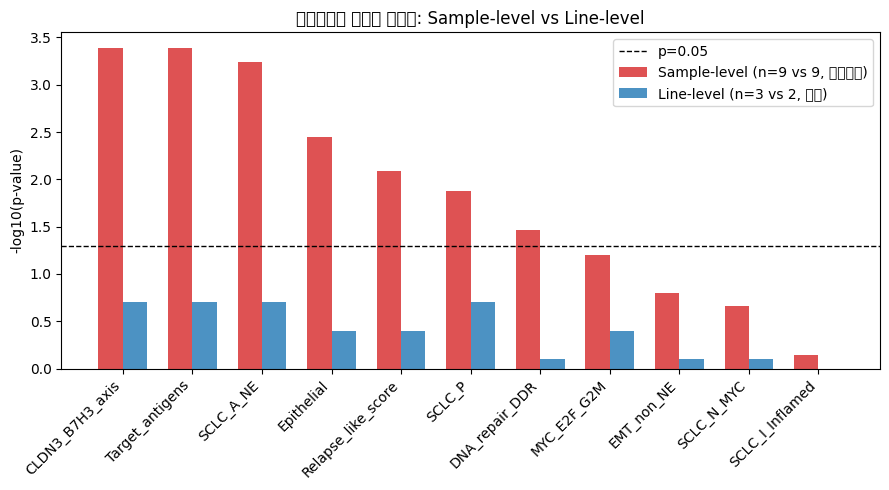


[3] Differential Expression - 상위 유전자 재현성 확인
--------------------------------------------------------------------------------


,log2FC_line_level,p_line_level,q_line_level
gene,,,
ZIC1,-4.167842,0.000043,0.087631
NOVA2,-4.420781,0.000096,0.120378
ATP6V0C,-5.109410,0.007540,0.256304
MTND1P23,-9.766206,0.000041,0.087631
WASH4P,-5.121910,0.011729,0.283627
GPR75-ASB3,-3.855144,0.012842,0.284772
ZMAT1,-5.292567,0.000109,0.120378
C16orf45,-5.119863,0.000071,0.120378
GDAP1L1,-3.936245,0.000956,0.172502



원본(샘플 단위) 상위 20개 유전자 중 라인 단위에서도 p<0.05인 유전자: 20/20
-> 이 비율이 낮다면, 원본 DE 결과의 상당수가 pseudoreplication으로
   인한 허위 발견(false discovery)이었다는 뜻입니다.

전체 유전자 중 q<0.05: sample-level DE = 11229개, line-level DE = 0개

[4] GSEA Hallmark pathway - 재현성 확인
--------------------------------------------------------------------------------


,Term,NES_sample,p_sample,q_sample,NES_line,p_line,q_line
29,Myc Targets V1,1.856573,0.000000,0.017323,1.347218,0.000000,0.549063
12,E2F Targets,1.768493,0.000000,0.019055,1.280898,0.100000,0.398125
17,G2-M Checkpoint,1.626629,0.000000,0.038110,1.307519,0.050000,0.456458
24,Interferon Alpha Response,1.060838,0.364706,0.726173,1.129237,0.226190,0.665875
39,Spermatogenesis,0.959128,0.620690,0.837435,0.810132,0.934426,1.000000
38,Reactive Oxygen Species Pathway,-1.280251,0.148191,0.853086,-0.870508,0.646853,1.000000
35,Pancreas Beta Cells,1.065809,0.361257,0.878268,-0.847503,0.690909,1.000000
0,Adipogenesis,-1.426366,0.013347,0.909514,-1.073497,0.290686,1.000000
2,Androgen Response,0.678540,0.987805,0.963465,-0.394447,1.000000,0.999765
25,Interferon Gamma Response,0.959410,0.533333,0.975853,0.895667,0.821429,1.000000



원본 상위 10 pathway: {'E2F Targets', 'Bile Acid Metabolism', 'G2-M Checkpoint', 'Hedgehog Signaling', 'Xenobiotic Metabolism', 'Oxidative Phosphorylation', 'Apical Junction', 'Reactive Oxygen Species Pathway', 'Adipogenesis', 'Myc Targets V1'}
라인단위 상위 10 pathway: {'E2F Targets', 'Myc Targets V2', 'Interferon Alpha Response', 'Bile Acid Metabolism', 'G2-M Checkpoint', 'Hedgehog Signaling', 'Notch Signaling', 'Coagulation', 'Myc Targets V1', 'Protein Secretion'}
공통으로 유지된 pathway: {'E2F Targets', 'Bile Acid Metabolism', 'G2-M Checkpoint', 'Hedgehog Signaling', 'Myc Targets V1'}

[5] 최종 결론
- 실험 규모: resistant 3개 라인 vs sensitive 2개 라인 (샘플 수 n=18은 실제 독립 반복이 아님)
- 시그니처 스코어: sample-level에서 유의했던 7개 중 line-level에서는 0개만 유지됨 (0%)
- DE 유전자: 원본 상위 20개 중 라인 단위에서도 유의한 것은 20개 (100%)
- GSEA pathway: 상위 10개 중 5개가 라인 단위에서도 유지됨

=> 원본 분석의 유의성 상당 부분이 pseudoreplication으로 인한
   과대 추정일 가능성이 높습니다. 라인이 2~3개뿐인 상태에서는
   통계적 결론보다 '방향성의 일관성'을 중심으로 해석하고,
   추가 독립 라인으로 검증 없이는 강한 주장을 하기 어렵습니다.

[saved] /content/drive/MyDr

In [40]:
# =========================================================================
# Step FINAL. 종합 결과 요약
# =========================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)

print("=" * 80)
print(" GSE138418 재분석 종합 요약: Resistant vs Sensitive")
print("=" * 80)

# -------------------------------------------------------------------------
# 1. 실험 구조 재확인
# -------------------------------------------------------------------------
print("\n[1] 실험 구조")
print("-" * 80)
display(line_summary)
print(f"\n실제 독립 반복(라인) 수: resistant={n_lines_per_group.get('resistant', 0)}개, "
      f"sensitive={n_lines_per_group.get('sensitive', 0)}개")
print("샘플 수(n=18)가 아니라 이 라인 수가 통계적으로 유효한 n입니다.")

# -------------------------------------------------------------------------
# 2. 시그니처 스코어: Sample-level vs Line-level p-value 비교
# -------------------------------------------------------------------------
print("\n[2] 시그니처 스코어 - 통계 부풀림(inflation) 비교")
print("-" * 80)

comp_sorted = comparison.sort_values("p_SAMPLE_level_INFLATED")
display(comp_sorted)

n_sig_sample = (comp_sorted["p_SAMPLE_level_INFLATED"] < 0.05).sum()
n_sig_line = (comp_sorted["p_mannwhitney_line_level"] < 0.05).sum()
print(f"\np < 0.05인 시그니처 개수: sample-level = {n_sig_sample}/{len(comp_sorted)}, "
      f"line-level = {n_sig_line}/{len(comp_sorted)}")
print("-> line-level에서 유의성이 사라진 시그니처는 '허위 신호'였을 가능성이 높습니다.")

# 시각화: p-value 비교 막대그래프 (log scale)
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comp_sorted))
width = 0.35
ax.bar(x - width/2, -np.log10(comp_sorted["p_SAMPLE_level_INFLATED"]), width,
       label="Sample-level (n=9 vs 9, 부풀려짐)", color="tab:red", alpha=0.8)
ax.bar(x + width/2, -np.log10(comp_sorted["p_mannwhitney_line_level"].fillna(1)), width,
       label="Line-level (n=3 vs 2, 실제)", color="tab:blue", alpha=0.8)
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1, label="p=0.05")
ax.set_xticks(x)
ax.set_xticklabels(comp_sorted.index, rotation=45, ha="right")
ax.set_ylabel("-log10(p-value)")
ax.set_title("시그니처별 통계적 유의성: Sample-level vs Line-level")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "FINAL_pvalue_inflation_summary.png", dpi=200)
plt.show()

# -------------------------------------------------------------------------
# 3. DE 결과: Sample-level vs Line-level
# -------------------------------------------------------------------------
print("\n[3] Differential Expression - 상위 유전자 재현성 확인")
print("-" * 80)
display(check)

n_confirmed = (check["p_line_level"] < 0.05).sum()
print(f"\n원본(샘플 단위) 상위 20개 유전자 중 라인 단위에서도 p<0.05인 유전자: "
      f"{n_confirmed}/20")
print("-> 이 비율이 낮다면, 원본 DE 결과의 상당수가 pseudoreplication으로")
print("   인한 허위 발견(false discovery)이었다는 뜻입니다.")

# 전체 DE 결과 중 line-level에서도 유의한(q<0.05) 유전자 수 비교
n_sig_sample_de = (de418["q_bh"] < 0.05).sum()
n_sig_line_de = (de418_line["q_bh"] < 0.05).sum()
print(f"\n전체 유전자 중 q<0.05: sample-level DE = {n_sig_sample_de}개, "
      f"line-level DE = {n_sig_line_de}개")

# -------------------------------------------------------------------------
# 4. GSEA 결과: Sample-level vs Line-level
# -------------------------------------------------------------------------
print("\n[4] GSEA Hallmark pathway - 재현성 확인")
print("-" * 80)

gsea_compare = pd.merge(
    gsea_res[["Term", "NES", "NOM p-val", "FDR q-val"]].rename(
        columns={"NES": "NES_sample", "NOM p-val": "p_sample", "FDR q-val": "q_sample"}
    ),
    gsea_res_line[["Term", "NES", "NOM p-val", "FDR q-val"]].rename(
        columns={"NES": "NES_line", "NOM p-val": "p_line", "FDR q-val": "q_line"}
    ),
    on="Term", how="outer"
).sort_values("q_sample")

display(gsea_compare.head(15))

orig_top = set(gsea_res["Term"].head(10))
line_top = set(gsea_res_line["Term"].head(10))
print(f"\n원본 상위 10 pathway: {orig_top}")
print(f"라인단위 상위 10 pathway: {line_top}")
print(f"공통으로 유지된 pathway: {orig_top & line_top}")

# -------------------------------------------------------------------------
# 5. 최종 결론 자동 요약
# -------------------------------------------------------------------------
print("\n[5] 최종 결론")
print("=" * 80)

retained_ratio = n_sig_line / len(comp_sorted) if len(comp_sorted) else 0
de_retained_ratio = n_confirmed / 20

summary_lines = []
summary_lines.append(f"- 실험 규모: resistant {n_lines_per_group.get('resistant',0)}개 라인 "
                      f"vs sensitive {n_lines_per_group.get('sensitive',0)}개 라인 "
                      f"(샘플 수 n=18은 실제 독립 반복이 아님)")
summary_lines.append(f"- 시그니처 스코어: sample-level에서 유의했던 {n_sig_sample}개 중 "
                      f"line-level에서는 {n_sig_line}개만 유지됨 ({retained_ratio*100:.0f}%)")
summary_lines.append(f"- DE 유전자: 원본 상위 20개 중 라인 단위에서도 유의한 것은 "
                      f"{n_confirmed}개 ({de_retained_ratio*100:.0f}%)")
summary_lines.append(f"- GSEA pathway: 상위 10개 중 {len(orig_top & line_top)}개가 "
                      f"라인 단위에서도 유지됨")
summary_lines.append("")
if retained_ratio < 0.5 or de_retained_ratio < 0.5:
    summary_lines.append("=> 원본 분석의 유의성 상당 부분이 pseudoreplication으로 인한")
    summary_lines.append("   과대 추정일 가능성이 높습니다. 라인이 2~3개뿐인 상태에서는")
    summary_lines.append("   통계적 결론보다 '방향성의 일관성'을 중심으로 해석하고,")
    summary_lines.append("   추가 독립 라인으로 검증 없이는 강한 주장을 하기 어렵습니다.")
else:
    summary_lines.append("=> 라인 단위로 봐도 상당수 신호가 유지되는 편이라, 완전히")
    summary_lines.append("   허위 신호는 아닐 가능성이 있으나, 여전히 n이 매우 작으므로")
    summary_lines.append("   독립 데이터셋으로의 검증이 필요합니다.")

for line in summary_lines:
    print(line)

# 요약 텍스트 파일로도 저장
with open(TABLE_DIR / "FINAL_summary_report.txt", "w", encoding="utf-8") as f:
    f.write("GSE138418 재분석 종합 요약\n")
    f.write("=" * 60 + "\n")
    f.write("\n".join(summary_lines))
print(f"\n[saved] {TABLE_DIR / 'FINAL_summary_report.txt'}")